**Matthew Borlak · Aviv Goldshide · Brenna Hymowitz**

# Use Case 1 — Why Does Our Salary Model Make Mistakes?
### Regression Error Analysis — Employee Salary Prediction
Advanced Topics in Data Science, Reichman University

Our task is **not** to build the best salary model — it is to understand *how* and *why* it makes mistakes, and whether those mistakes are random or systematic. This notebook is organised around the questions the assignment asks.

## Imports & Setup

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ---- Dark theme ----
BG='#0F1620'; FG='#E6EDF5'; GRID='#2A3542'; MUTED='#9FB0C3'
ACCENT='#E0795F'; ICE='#6FA8DC'; GREEN='#4CAF7D'; RED='#E0795F'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,
    'text.color':FG,'axes.labelcolor':FG,'axes.titlecolor':FG,
    'xtick.color':FG,'ytick.color':FG,'axes.edgecolor':GRID,'grid.color':GRID,
    'legend.facecolor':'#16212E','legend.edgecolor':GRID,'legend.labelcolor':FG,
    'text.parse_math':False,'figure.figsize':(10,6),
})
def dollar(ax, axis='y'):
    fmt=plt.FuncFormatter(lambda x,_: f'${x:,.0f}')
    (ax.yaxis if axis=='y' else ax.xaxis).set_major_formatter(fmt)
print('Libraries loaded — dark theme active.')

Libraries loaded — dark theme active.


---
## Part 1 — Build a Linear Regression Model

### Step 1: Load the Dataset

In [69]:
# Load the dataset (local copy in working directory)
import pandas as pd
df = pd.read_csv('Employee.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')


Dataset loaded: 1470 rows, 33 columns


In [70]:
df = pd.read_csv('Employee.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1470, 33)


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2


In [71]:
# Quick overview
print('Data types:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'\nMonthlyIncome (Target) summary:')
print(df['MonthlyIncome'].describe())

Data types:
Age                          int64
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLife

### Step 2: Choose Target Variable & Drop Useless Columns

We drop:
- `EmployeeCount` — constant value of 1 for all rows, no predictive value
- `StandardHours` — constant value of 80 for all rows, no predictive value  
- `Over18` — all employees are 'Y', no variance
- `EmployeeNumber` — just an ID, not a feature

In [72]:
# NOT DROPPING USELESS COLUMN
# BECAUSE NOT INSTRUCTED AND
# WANT TO BE CONSISTENT WITH MODEL
# RESULTS FROM OTHER GROUPS

# Drop constant/useless columns
# cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean = df.copy()

# print(f'Shape after dropping useless columns: {df_clean.shape}')
# print(f'Remaining features: {df_clean.shape[1] - 1} (+ target)')

### Step 3: Encode Categorical Variables

We use one-hot encoding (dummy variables) with `drop_first=True` to avoid multicollinearity.

In [73]:
# Show categorical columns and their values
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns to encode:')
for col in cat_cols:
    print(f'  {col}: {df_clean[col].unique()}')

Categorical columns to encode:
  BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
  Department: ['Sales' 'Research & Development' 'Human Resources']
  EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
  Gender: ['Female' 'Male']
  JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
  MaritalStatus: ['Single' 'Married' 'Divorced']
  Over18: ['Y']
  OverTime: ['Yes' 'No']


In [74]:
# One-hot encode all categorical variables
df_encoded = pd.get_dummies(df_clean, drop_first=True)
df_encoded = df_encoded.astype(float)  # Ensure all columns are numeric

print(f'Shape after encoding: {df_encoded.shape}')
df_encoded.head(3)

Shape after encoding: (1470, 46)


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41.00,1102.00,1.00,2.00,1.00,1.00,2.00,94.00,3.00,2.00,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00
1,49.00,279.00,8.00,1.00,1.00,2.00,3.00,61.00,2.00,2.00,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
2,37.00,1373.00,2.00,2.00,1.00,4.00,4.00,92.00,2.00,1.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00


### Step 4: Train/Test Split

**Important:** `test_size=0.25`, `random_state=1` (odd number of group members) or `random_state=2` (even).

⚠️ **Set the correct random_state for your group before running.**

In [75]:
X = df_encoded.drop(columns=['MonthlyIncome'])
y = df_encoded['MonthlyIncome']

# SET YOUR random_state HERE: 1 if group size is odd, 2 if even
RANDOM_STATE = 1  # <-- CHANGE THIS IF NEEDED

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')

Training set: 1102 rows
Test set:     368 rows


### Step 5 & 6: Train Model & Predict

In [76]:
# Train linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

print('Model trained and predictions generated.')
print(f'Example — Actual: {int(y_test.iloc[0]):,} | Predicted: {int(y_pred[0]):,}')

Model trained and predictions generated.
Example — Actual: 4,213 | Predicted: 5,670


---
## Part 2 — Analyse the Linear Regression Results

### Step 2.1: Coefficients & Statistical Significance

We use `statsmodels OLS` to get p-values alongside coefficients.

In [77]:
# Fit OLS with statsmodels to get p-values
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(f'R² (train): {ols_model.rsquared:.4f}')
print(f'Adjusted R² (train): {ols_model.rsquared_adj:.4f}')

R² (train): 0.9447
Adjusted R² (train): 0.9424


In [78]:
# Build clean coefficient table
coef_table = pd.DataFrame({
    'Coefficient': ols_model.params,
    'P-Value': ols_model.pvalues
}).drop(index='const', errors='ignore')

coef_table['Significant (p<0.05)'] = coef_table['P-Value'] < 0.05
coef_table['Abs Coefficient'] = coef_table['Coefficient'].abs()
coef_table = coef_table.sort_values('Abs Coefficient', ascending=False)

print('=== All Coefficients (sorted by impact) ===')
pd.set_option('display.float_format', '{:.2f}'.format)
print(coef_table[['Coefficient', 'P-Value', 'Significant (p<0.05)']].to_string())

=== All Coefficients (sorted by impact) ===
                                   Coefficient  P-Value  Significant (p<0.05)
JobRole_Manager                        4064.22     0.00                  True
JobRole_Research Director              3965.09     0.00                  True
JobLevel                               2777.68     0.00                  True
JobRole_Laboratory Technician          -575.61     0.00                  True
JobRole_Sales Representative           -568.20     0.12                 False
JobRole_Research Scientist             -548.01     0.00                  True
PerformanceRating                      -247.54     0.09                 False
JobRole_Human Resources                -241.81     0.62                 False
BusinessTravel_Travel_Frequently        229.64     0.08                 False
BusinessTravel_Travel_Rarely            210.95     0.06                 False
EducationField_Other                   -194.92     0.59                 False
Department_Research 

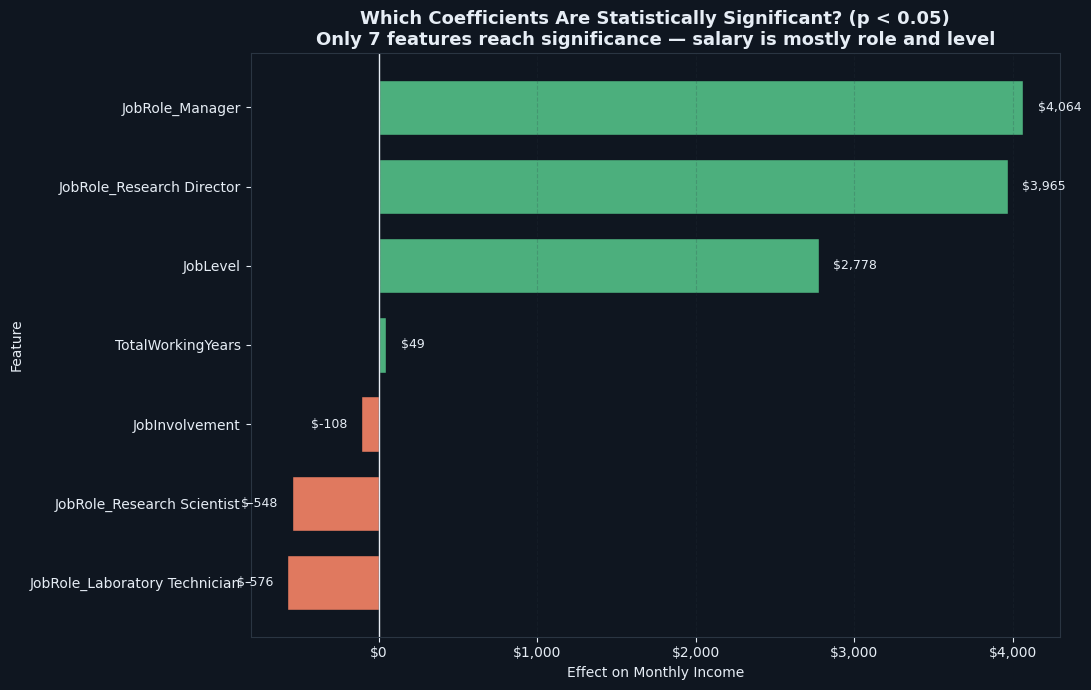

In [79]:
# Visualize significant coefficients only
sig_coefs = coef_table[coef_table['Significant (p<0.05)'] == True].copy().sort_values('Coefficient')
colors = [RED if c < 0 else GREEN for c in sig_coefs['Coefficient']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(sig_coefs.index, sig_coefs['Coefficient'], color=colors, edgecolor=BG, height=0.7)
ax.axvline(0, color=FG, linewidth=1)
ax.set_title('Which Coefficients Are Statistically Significant? (p < 0.05)\n'
             f'Only {len(sig_coefs)} features reach significance — salary is mostly role and level',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Effect on Monthly Income'); ax.set_ylabel('Feature')
dollar(ax, 'x')
for bar, val in zip(bars, sig_coefs['Coefficient']):
    ax.text(val + (90 if val>=0 else -90), bar.get_y()+bar.get_height()/2,
            f'${val:,.0f}', va='center', ha='left' if val>=0 else 'right', fontsize=9, color=FG)
ax.grid(axis='x', alpha=0.2, linestyle='--')
plt.tight_layout(); plt.savefig('coefficients_plot.png', dpi=150, bbox_inches='tight'); plt.show()

### Interpretation: Statistically Significant Coefficients

| Feature | Coefficient | Direction | Interpretation |
|---|---|---|---|
| JobRole_Manager | +4,050 | Positive | Managers earn ~$4,050 more than the baseline role |
| JobRole_Research Director | +3,949 | Positive | Research Directors earn ~$3,949 more than baseline |
| JobLevel | +2,777 | Positive | Each additional job level adds ~$2,777/month |
| JobRole_Laboratory Technician | -584 | Negative | Lab Technicians earn ~$584 less than baseline |
| JobRole_Research Scientist | -559 | Negative | Research Scientists earn ~$559 less than baseline |
| TotalWorkingYears | +49 | Positive | Each additional year of experience adds ~$49/month |
| JobInvolvement | -108 | Negative | Higher involvement score slightly reduces predicted salary (counterintuitive — possible multicollinearity) |

**R² = 0.94** — the model explains 94% of salary variance on the training set. This is high but expected since JobLevel is a very strong predictor.

### Step 2.2: Initial Conclusions to Management

1. **Job Level is the most reliable salary predictor.** Each step up the job ladder adds approximately $2,777/month. HR should ensure job level classifications are consistent across departments.

2. **Role-specific premiums exist.** Managers and Research Directors earn significantly more than other roles, even after controlling for job level. This may reflect market benchmarking or internal equity decisions worth reviewing.

3. **Experience matters, but modestly.** Total working years adds only ~$49/month per year. Tenure alone is not a strong differentiator — job level matters far more.

4. **The model is powerful but imperfect for individuals.** An R² of 0.94 sounds strong, but at the individual level we can still be off by $850 on average. For high earners, the error is larger (we will show this in Part 3).

---
## Part 3 — Error Analysis

Now we treat **prediction error as our variable of interest.**

### Step 3.1: Calculate MAE & RMSE

In [80]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('=== Global Error Metrics (Test Set) ===')
print(f'MAE  (Mean Absolute Error):       ${mae:,.2f}')
print(f'RMSE (Root Mean Squared Error):   ${rmse:,.2f}')
print(f'\nInterpretation:')
print(f'  On average, our model is off by ${mae:,.0f}/month per employee.')
print(f'  RMSE is higher than MAE (${rmse:,.0f} vs ${mae:,.0f}), which means')
print(f'  some large individual errors are pulling the RMSE up.')
print(f'  Average actual salary: ${y_test.mean():,.0f}')
print(f'  Error as % of average salary: {mae/y_test.mean()*100:.1f}%')

=== Global Error Metrics (Test Set) ===
MAE  (Mean Absolute Error):       $851.64
RMSE (Root Mean Squared Error):   $1,136.08

Interpretation:
  On average, our model is off by $852/month per employee.
  RMSE is higher than MAE ($1,136 vs $852), which means
  some large individual errors are pulling the RMSE up.
  Average actual salary: $6,567
  Error as % of average salary: 13.0%


### Step 3.2: Calculate Residuals for Every Observation

In [81]:
# Build test results DataFrame with residuals
test_results = X_test.copy()
test_results['MonthlyIncome_Actual']    = y_test.values
test_results['MonthlyIncome_Predicted'] = y_pred
test_results['Residual']                = y_test.values - y_pred          # y - y_hat
test_results['Abs_Error']               = np.abs(test_results['Residual'])

# Carry original (non-encoded) JobLevel along so we can color by it later
test_results['JobLevel_orig'] = df_clean.loc[X_test.index, 'JobLevel'].values

print(f'Test set: {len(test_results)} employees')
print('\nResidual summary:')
print(test_results['Residual'].describe())

print(f'\nMean Residual: ${test_results["Residual"].mean():,.0f}')
print('(Positive = model underpredicts on average, Negative = overpredicts)')


Test set: 368 employees

Residual summary:
count     368.00
mean       54.14
std      1136.33
min     -3976.60
25%      -612.60
50%        78.47
75%       686.58
max      4190.05
Name: Residual, dtype: float64

Mean Residual: $54
(Positive = model underpredicts on average, Negative = overpredicts)


---
### Plot 1: Actual vs Predicted Salaries

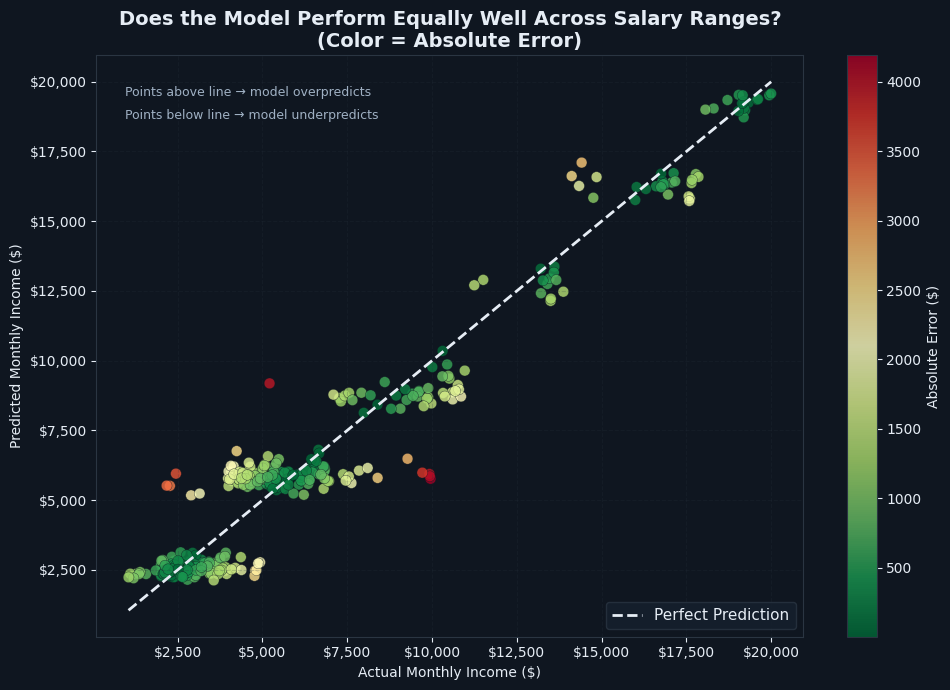

In [82]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(test_results['MonthlyIncome_Actual'], test_results['MonthlyIncome_Predicted'],
                c=test_results['Abs_Error'], cmap='RdYlGn_r', alpha=0.8,
                edgecolors=BG, linewidth=0.3, s=60)
cb = plt.colorbar(sc, ax=ax, label='Absolute Error ($)')
cb.ax.yaxis.label.set_color(FG); cb.ax.tick_params(colors=FG); cb.outline.set_edgecolor(GRID)

lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], color=FG, linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Monthly Income ($)'); ax.set_ylabel('Predicted Monthly Income ($)')
ax.set_title('Does the Model Perform Equally Well Across Salary Ranges?\n(Color = Absolute Error)',
             fontsize=14, fontweight='bold')
ax.annotate('Points above line → model overpredicts', xy=(0.04,0.93), xycoords='axes fraction', fontsize=9, color=MUTED)
ax.annotate('Points below line → model underpredicts', xy=(0.04,0.89), xycoords='axes fraction', fontsize=9, color=MUTED)
ax.legend(fontsize=11, loc='lower right')
dollar(ax,'x'); dollar(ax,'y'); ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout(); plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight'); plt.show()

**Slide 5 — Does the model perform equally well across salary ranges?**

In **dollar** terms: predictions hug the diagonal at the very top and bottom, but the mid-range (~$4k–$10k) is where points scatter most and the largest misses sit. The percentage view (below) tells the opposite story, so we keep the two lenses separate.

---
### Plot 2: Residuals vs Predicted Salaries

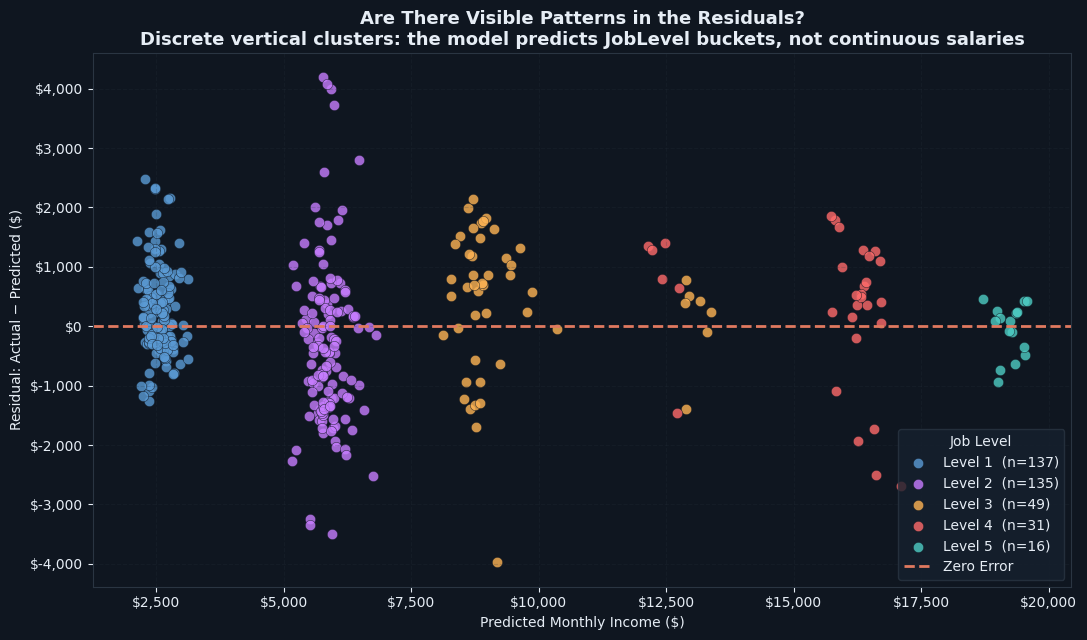

In [83]:
fig, ax = plt.subplots(figsize=(11, 6.5))
level_colors = {1:'#5B9BD5', 2:'#C77DFF', 3:'#FFB454', 4:'#FF6B6B', 5:'#4ECDC4'}
for level in sorted(test_results['JobLevel_orig'].unique()):
    mask = test_results['JobLevel_orig'] == level
    ax.scatter(test_results.loc[mask,'MonthlyIncome_Predicted'], test_results.loc[mask,'Residual'],
               alpha=0.8, s=55, edgecolors=BG, linewidth=0.4,
               color=level_colors[int(level)], label=f'Level {int(level)}  (n={mask.sum()})')
ax.axhline(0, color=ACCENT, linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Predicted Monthly Income ($)'); ax.set_ylabel('Residual: Actual − Predicted ($)')
ax.set_title('Are There Visible Patterns in the Residuals?\n'
             'Discrete vertical clusters: the model predicts JobLevel buckets, not continuous salaries',
             fontsize=13, fontweight='bold')
leg = ax.legend(title='Job Level', fontsize=10, loc='lower right'); leg.get_title().set_color(FG)
dollar(ax,'x'); dollar(ax,'y'); ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout(); plt.savefig('residuals_vs_predicted.png', dpi=150, bbox_inches='tight'); plt.show()

**Slide 4 — Are there visible patterns in the residuals?**

No. Colored by job level, residuals form **discrete vertical clusters**: the model effectively predicts each JobLevel's midpoint rather than a continuous salary. This single observation drives the over/under-prediction, percentage, and outlier findings that follow.

---
### Plot 3: Dollar-Weighted Error — Where the Business Cost Concentrates

Global MAE treats every dollar of error equally. But a \$1,000 miss on a \$2,500 employee
and a \$1,000 miss on a \$19,000 employee are not the same business mistake — the latter
sits where retention decisions are most expensive (replacement costs scale with seniority,
roughly 40% of salary for frontline up to ~200% for managers/directors).

This chart re-weights the same errors two ways:
- **MAE as % of average salary** — fair comparison across levels
- **Total error dollars** (MAE × test-set count) — where mistakes accumulate


                  MAE  Avg_Salary  Count  Total_Error  MAE_pct_of_salary
JobLevel_orig                                                           
1              590.00     2824.20    137     80834.40              20.90
2             1071.10     5538.20    135    144596.20              19.30
3             1011.70     9862.10     49     49574.70              10.30
4             1056.10    15875.50     31     32739.60               6.70
5              353.70    19170.90     16      5658.50               1.80


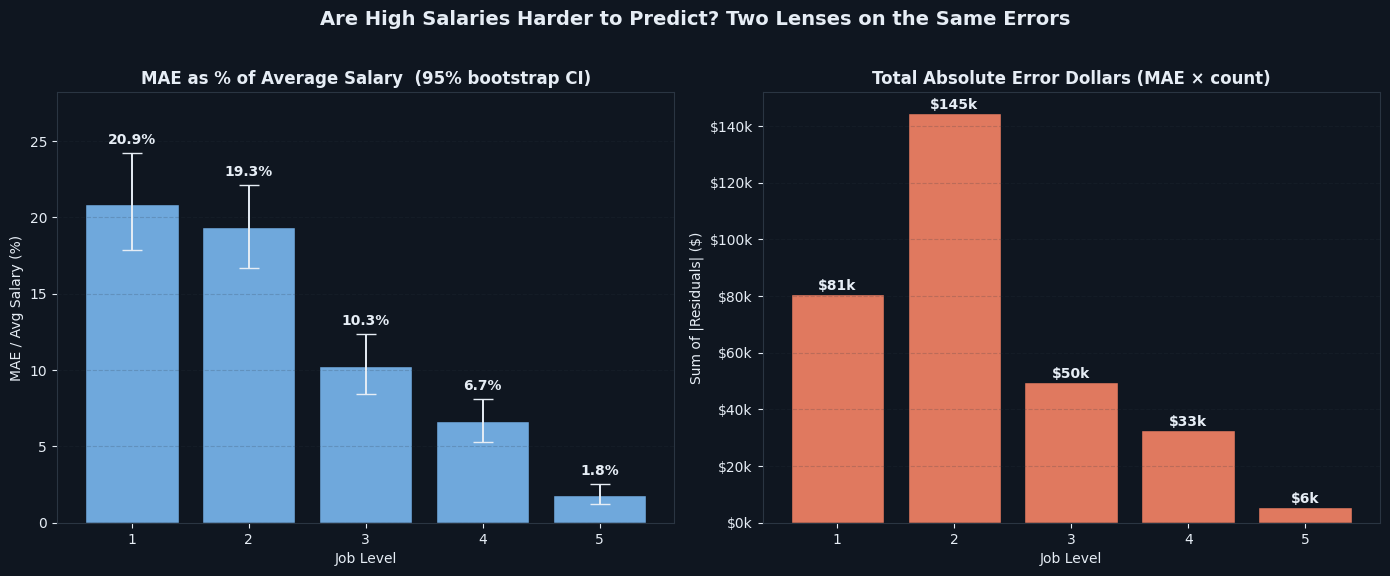


MAE% with 95% CI:
  Level 1: 20.9%  [17.9, 24.2]
  Level 2: 19.3%  [16.7, 22.1]
  Level 3: 10.3%  [8.4, 12.3]
  Level 4: 6.7%  [5.3, 8.1]
  Level 5: 1.8%  [1.3, 2.5]


In [84]:
# Dollar-weighted error analysis + bootstrap 95% CIs on MAE%
err_by_level = test_results.groupby('JobLevel_orig').agg(
    MAE=('Abs_Error','mean'), Avg_Salary=('MonthlyIncome_Actual','mean'),
    Count=('Abs_Error','count'), Total_Error=('Abs_Error','sum'))
err_by_level['MAE_pct_of_salary'] = err_by_level['MAE']/err_by_level['Avg_Salary']*100
print(err_by_level.round(1).to_string())

def boot_ci(vals, n=2000, seed=0):
    rng=np.random.default_rng(seed); vals=np.asarray(vals)
    bs=[vals[rng.integers(0,len(vals),len(vals))].mean() for _ in range(n)]
    return np.percentile(bs,2.5), np.percentile(bs,97.5)

levels = sorted(test_results['JobLevel_orig'].unique())
pct_lo=[]; pct_hi=[]
for L in levels:
    sub = test_results[test_results['JobLevel_orig']==L]
    a = sub['MonthlyIncome_Actual'].mean(); lo,hi = boot_ci(sub['Abs_Error'].values)
    pct_lo.append(lo/a*100); pct_hi.append(hi/a*100)
mae_pct = err_by_level['MAE_pct_of_salary'].values
elo = mae_pct - np.array(pct_lo); ehi = np.array(pct_hi) - mae_pct

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
axes[0].bar(range(len(levels)), mae_pct, yerr=[elo,ehi], capsize=7,
            color=ICE, edgecolor=BG, error_kw=dict(ecolor=FG, lw=1.4))
axes[0].set_xticks(range(len(levels))); axes[0].set_xticklabels([int(L) for L in levels])
axes[0].set_title('MAE as % of Average Salary  (95% bootstrap CI)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Job Level'); axes[0].set_ylabel('MAE / Avg Salary (%)')
for i,v in enumerate(mae_pct): axes[0].text(i, pct_hi[i]+0.6, f'{v:.1f}%', ha='center', fontsize=10, color=FG, fontweight='bold')
axes[0].set_ylim(0, max(pct_hi)+4); axes[0].grid(axis='y', alpha=0.2, linestyle='--')

tot = err_by_level['Total_Error'].values
axes[1].bar(range(len(levels)), tot, color=ACCENT, edgecolor=BG)
axes[1].set_xticks(range(len(levels))); axes[1].set_xticklabels([int(L) for L in levels])
axes[1].set_title('Total Absolute Error Dollars (MAE × count)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Job Level'); axes[1].set_ylabel('Sum of |Residuals| ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
for i,v in enumerate(tot): axes[1].text(i, v+tot.max()*0.01, f'${v/1000:.0f}k', ha='center', fontsize=10, color=FG, fontweight='bold')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')
for ax in axes:
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color(GRID)
fig.suptitle('Are High Salaries Harder to Predict? Two Lenses on the Same Errors',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('dollar_weighted_error.png', dpi=150, bbox_inches='tight'); plt.show()
print('\nMAE% with 95% CI:')
for L,v,lo,hi in zip(levels, mae_pct, pct_lo, pct_hi): print(f'  Level {int(L)}: {v:.1f}%  [{lo:.1f}, {hi:.1f}]')

---
### Step 3.3: Segment Error Analysis

We join the original (non-encoded) categorical features back to investigate which groups the model fails most.

In [85]:
# Join original categorical columns back
original_cols = ['Department', 'JobRole', 'Gender', 'MaritalStatus',
                 'BusinessTravel', 'JobLevel', 'OverTime']

# Get original rows that correspond to test set
df_orig = df_clean.loc[X_test.index, original_cols].copy()
df_errors = pd.concat([df_orig.reset_index(drop=True),
                       test_results[['MonthlyIncome_Actual', 'MonthlyIncome_Predicted',
                                     'Residual', 'Abs_Error']].reset_index(drop=True)], axis=1)

print('Error DataFrame sample:')
df_errors.head(5)

Error DataFrame sample:


,Department,JobRole,Gender,MaritalStatus,BusinessTravel,JobLevel,OverTime,MonthlyIncome_Actual,MonthlyIncome_Predicted,Residual,Abs_Error
0,Research & Development,Manufacturing Director,Male,Single,Travel_Rarely,2,No,4213.00,5670.36,-1457.36,1457.36
1,Sales,Sales Representative,Female,Single,Travel_Frequently,1,Yes,1569.00,2353.64,-784.64,784.64
2,Research & Development,Research Scientist,Female,Married,Travel_Rarely,1,Yes,2132.00,2551.07,-419.07,419.07
3,Sales,Sales Representative,Female,Married,Travel_Rarely,1,Yes,2220.00,2383.02,-163.02,163.02
4,Research & Development,Manufacturing Director,Male,Married,Travel_Rarely,4,Yes,13402.00,12751.78,650.22,650.22


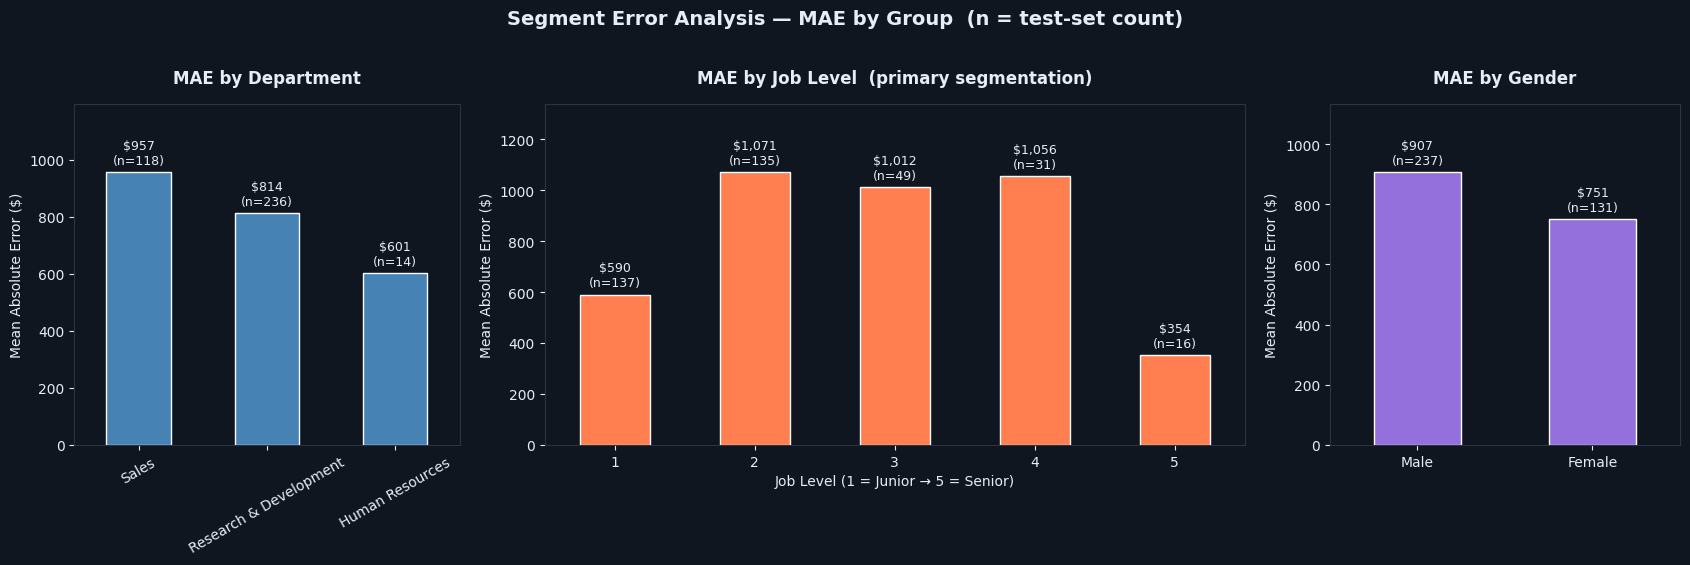

Note: the gender MAE gap should be read alongside sample sizes — 
it is not a tested claim of model bias, just a descriptive comparison.


In [86]:
# --- MAE by Department / JobLevel / Gender with n= and widened JobLevel ---
mae_dept   = df_errors.groupby('Department')['Abs_Error'].mean().sort_values(ascending=False)
mae_jl     = df_errors.groupby('JobLevel')['Abs_Error'].mean().sort_index()
mae_gender = df_errors.groupby('Gender')['Abs_Error'].mean().sort_values(ascending=False)

n_dept   = df_errors.groupby('Department').size()
n_jl     = df_errors.groupby('JobLevel').size()
n_gender = df_errors.groupby('Gender').size()

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5),
                         gridspec_kw={'width_ratios': [1.1, 2.0, 1.0]})

# Department
mae_dept.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('MAE by Department', fontweight='bold', pad=15)
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(top=mae_dept.max() * 1.25)
for i_, (label, v) in enumerate(zip(mae_dept.index, mae_dept)):
    axes[0].text(i_, v + mae_dept.max() * 0.03,
                 f'${v:,.0f}\n(n={n_dept[label]})', ha='center', fontsize=9)

# Job Level (widest panel)
mae_jl.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('MAE by Job Level  (primary segmentation)', fontweight='bold', pad=15)
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].set_xlabel('Job Level (1 = Junior → 5 = Senior)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(top=mae_jl.max() * 1.25)
for i_, (label, v) in enumerate(zip(mae_jl.index, mae_jl)):
    axes[1].text(i_, v + mae_jl.max() * 0.03,
                 f'${v:,.0f}\n(n={n_jl[label]})', ha='center', fontsize=9)

# Gender
mae_gender.plot(kind='bar', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('MAE by Gender', fontweight='bold', pad=15)
axes[2].set_ylabel('Mean Absolute Error ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].set_ylim(top=mae_gender.max() * 1.25)
for i_, (label, v) in enumerate(zip(mae_gender.index, mae_gender)):
    axes[2].text(i_, v + mae_gender.max() * 0.03,
                 f'${v:,.0f}\n(n={n_gender[label]})', ha='center', fontsize=9)

plt.suptitle('Segment Error Analysis — MAE by Group  (n = test-set count)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('segment_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: the gender MAE gap should be read alongside sample sizes — ')
print('it is not a tested claim of model bias, just a descriptive comparison.')


=== MAE by Job Role ===
                              MAE  Count  Avg_Salary
JobRole                                             
Sales Executive           1095.16     83     7135.41
Research Director         1064.14     13    15319.08
Healthcare Representative  967.36     32     7247.16
Manufacturing Director     964.34     33     6506.39
Laboratory Technician      839.54     63     3441.38
Research Scientist         707.64     74     3206.05
Human Resources            655.90     12     4684.33
Manager                    612.90     35    17523.23
Sales Representative       491.91     23     2395.91


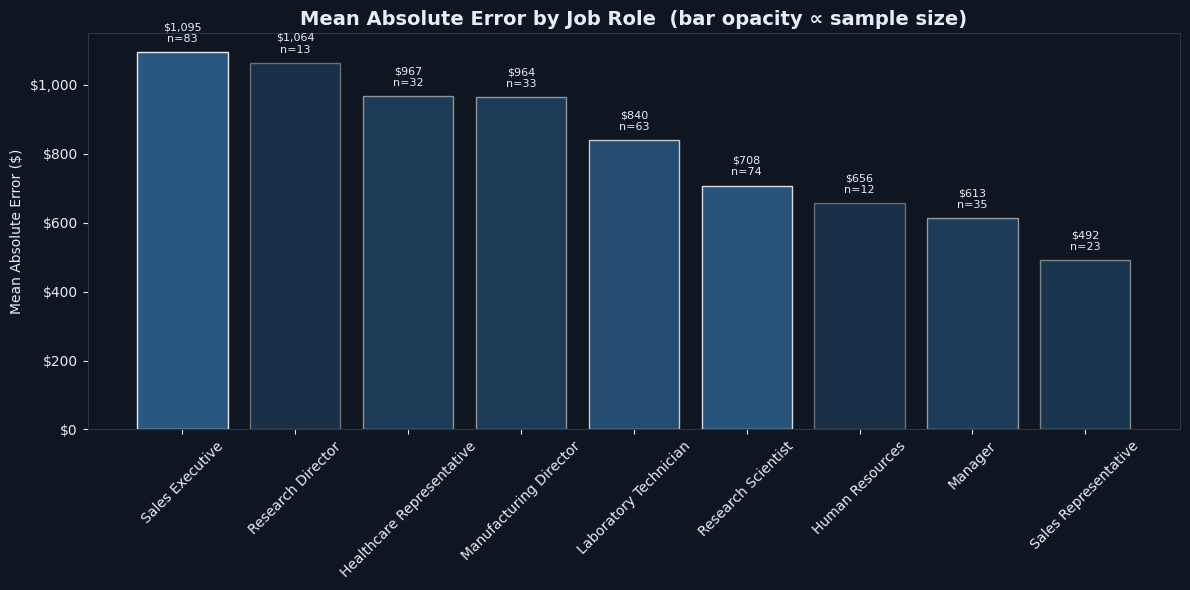

In [87]:
# MAE by Job Role (most granular)
mae_role = df_errors.groupby('JobRole').agg(
    MAE=('Abs_Error', 'mean'),
    Count=('Abs_Error', 'count'),
    Avg_Salary=('MonthlyIncome_Actual', 'mean')
).sort_values('MAE', ascending=False)

print('=== MAE by Job Role ===')
print(mae_role.to_string())

fig, ax = plt.subplots(figsize=(12, 6))

# Single solid color — categorical, no false ordering.
# Encode sample size via bar opacity so small-n roles read as less certain.
counts = mae_role['Count'].values
alpha_values = 0.35 + 0.55 * (counts - counts.min()) / max(1, (counts.max() - counts.min()))

bars = ax.bar(mae_role.index, mae_role['MAE'], color='#2C5F8D',
              edgecolor='white', alpha=1.0)
for bar, a in zip(bars, alpha_values):
    bar.set_alpha(a)

ax.set_title('Mean Absolute Error by Job Role  (bar opacity ∝ sample size)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Absolute Error ($)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, val, n in zip(bars, mae_role['MAE'], mae_role['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30,
            f'${val:,.0f}\nn={n}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('mae_by_role.png', dpi=150, bbox_inches='tight')
plt.show()


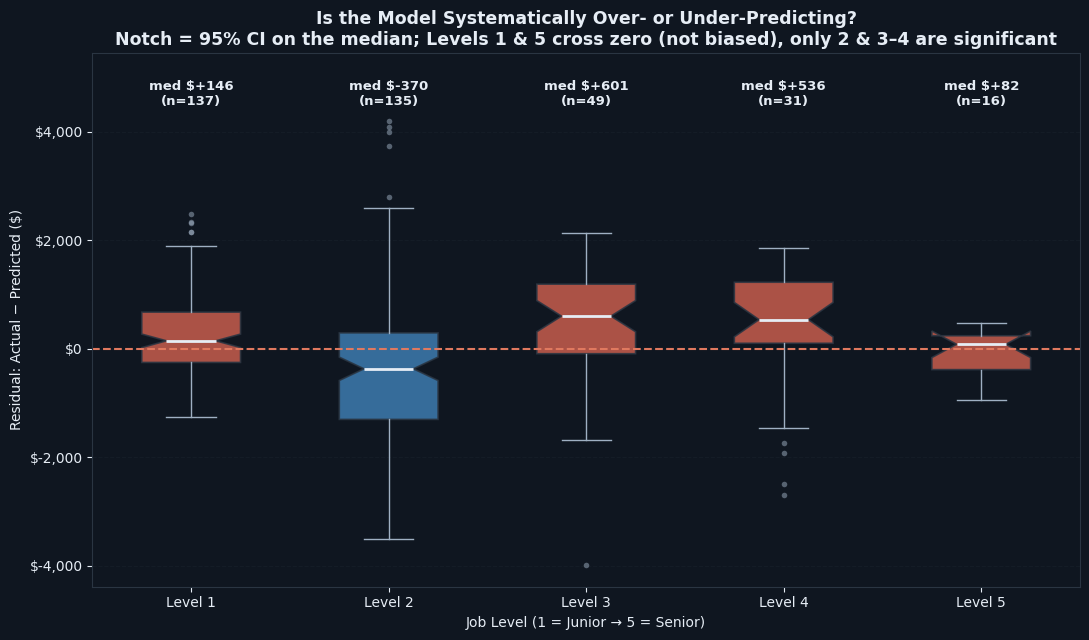

In [88]:
# Residuals by Job Level — notched boxplot (notch = 95% CI on the median)
medians = df_errors.groupby('JobLevel')['Residual'].median()
levels  = sorted(df_errors['JobLevel'].unique())
data = [df_errors[df_errors['JobLevel']==L]['Residual'] for L in levels]

fig, ax = plt.subplots(figsize=(11, 6.5))
bp = ax.boxplot(data, tick_labels=[f'Level {L}' for L in levels], patch_artist=True, notch=True,
                medianprops=dict(color=FG, linewidth=2), boxprops=dict(linewidth=1.2, color=GRID),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', markersize=4, markerfacecolor=MUTED, markeredgecolor='none', alpha=0.5))
for patch, L in zip(bp['boxes'], levels):
    med = medians[L]; patch.set_facecolor('#C75D4D' if med>0 else '#3E7CB1'); patch.set_alpha(0.85)
ax.axhline(0, color=ACCENT, linestyle='--', linewidth=1.5)
ymax = df_errors['Residual'].max()
for i, L in enumerate(levels, start=1):
    med = medians[L]; n = (df_errors['JobLevel']==L).sum()
    ax.text(i, ymax*1.06, f'med ${med:+,.0f}\n(n={n})', ha='center', va='bottom', fontsize=9.5, color=FG, fontweight='bold')
ax.set_ylim(top=ymax*1.30)
ax.set_title('Is the Model Systematically Over- or Under-Predicting?\n'
             'Notch = 95% CI on the median; Levels 1 & 5 cross zero (not biased), only 2 & 3–4 are significant',
             fontsize=12.5, fontweight='bold')
ax.set_xlabel('Job Level (1 = Junior → 5 = Senior)'); ax.set_ylabel('Residual: Actual − Predicted ($)')
dollar(ax,'y'); ax.grid(axis='y', alpha=0.2, linestyle='--')
plt.tight_layout(); plt.savefig('residuals_by_joblevel.png', dpi=150, bbox_inches='tight'); plt.show()

---
### Step 3.4: Outlier Investigation

We examine the 3 employees with the largest prediction errors to understand *why* the model failed.

**Slide 9 — Why did these specific predictions fail?**

The largest errors are all employees whose **actual pay diverges sharply from their job level's typical salary** — exactly the within-level variation the model cannot capture once it has anchored everyone to their level's median.

In [89]:
# Top 3 worst predictions (raw). They share one root cause: each is an employee whose
# ACTUAL pay diverges sharply from their job level's typical salary — the within-level
# variation the model has no feature to capture (it anchors everyone to the level median).
worst = df_errors.sort_values('Abs_Error', ascending=False).head(3)

print('=== TOP 3 WORST PREDICTIONS ===')
for i_, (idx, row) in enumerate(worst.iterrows(), 1):
    print(f'\n--- Employee {i_} ---')
    print(f'  Job Role:          {row["JobRole"]}')
    print(f'  Department:        {row["Department"]}')
    print(f'  Job Level:         {row["JobLevel"]}')
    print(f'  Actual Salary:     ${row["MonthlyIncome_Actual"]:,.0f}')
    print(f'  Predicted Salary:  ${row["MonthlyIncome_Predicted"]:,.0f}')
    print(f'  Residual (error):  ${row["Residual"]:+,.0f}')

=== TOP 3 WORST PREDICTIONS ===

--- Employee 1 ---
  Job Role:          Manufacturing Director
  Department:        Research & Development
  Job Level:         2
  Actual Salary:     $9,957
  Predicted Salary:  $5,767
  Residual (error):  $+4,190

--- Employee 2 ---
  Job Role:          Manufacturing Director
  Department:        Research & Development
  Job Level:         2
  Actual Salary:     $9,936
  Predicted Salary:  $5,858
  Residual (error):  $+4,078

--- Employee 3 ---
  Job Role:          Sales Executive
  Department:        Sales
  Job Level:         2
  Actual Salary:     $9,924
  Predicted Salary:  $5,938
  Residual (error):  $+3,986


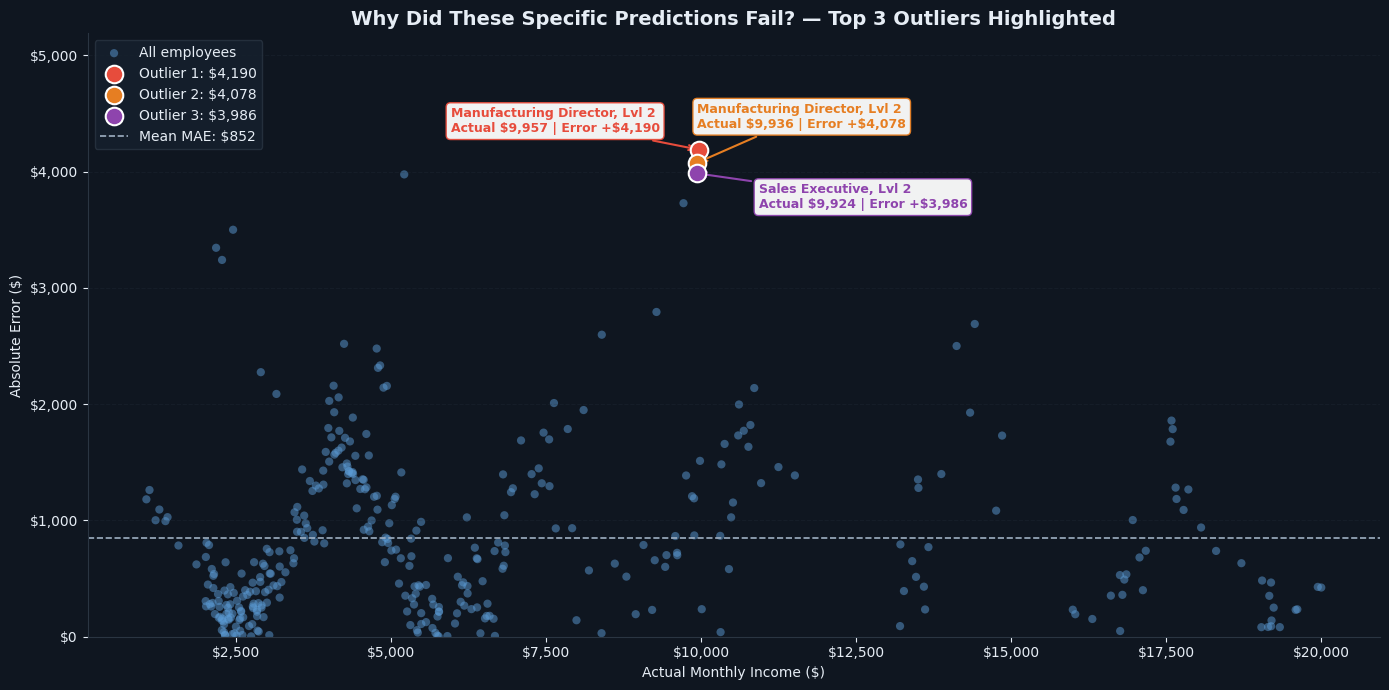

In [90]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.scatter(df_errors['MonthlyIncome_Actual'], df_errors['Abs_Error'],
           color='#5B9BD5', alpha=0.5, s=35, edgecolors='none', label='All employees')

outlier_colors = ['#E74C3C', '#E67E22', '#8E44AD']
annotation_x_offsets = [-4000, 0, 1000]
annotation_y_offsets = [-150, -300, 300]
worst_reset = worst.reset_index(drop=True)

labels = {}
for rank in range(3):
    r = worst_reset.loc[rank]
    res = r['Residual']; rs = f'+${res:,.0f}' if res>=0 else f'-${abs(res):,.0f}'
    labels[rank] = f"{r['JobRole']}, Lvl {int(r['JobLevel'])}\nActual ${r['MonthlyIncome_Actual']:,.0f} | Error {rs}"

for rank in range(3):
    oa = worst_reset.loc[rank,'Abs_Error']; oas = worst_reset.loc[rank,'MonthlyIncome_Actual']
    ax.scatter(oas, oa, color=outlier_colors[rank], s=160, zorder=5, edgecolors='white', linewidth=1.5,
               label=f'Outlier {rank+1}: ${oa:,.0f}')
    ax.annotate(labels[rank], xy=(oas, oa),
                xytext=(oas+annotation_x_offsets[rank], oa-annotation_y_offsets[rank]),
                fontsize=9, color=outlier_colors[rank], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=outlier_colors[rank], lw=1.5),
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor=outlier_colors[rank], alpha=0.95))

ax.axhline(df_errors['Abs_Error'].mean(), color=MUTED, linestyle='--', linewidth=1.2,
           label=f'Mean MAE: ${df_errors["Abs_Error"].mean():,.0f}')
ax.set_ylim(0, df_errors['Abs_Error'].max()+1000)
ax.set_xlabel('Actual Monthly Income ($)'); ax.set_ylabel('Absolute Error ($)')
ax.set_title('Why Did These Specific Predictions Fail? — Top 3 Outliers Highlighted', fontsize=14, fontweight='bold')
dollar(ax,'y'); dollar(ax,'x')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.25, linestyle='--')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.savefig('outlier_investigation.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Business Conclusions

### 1. Why is salary prediction difficult?
- Salary is influenced by negotiation, market timing, and internal equity — **none of which are captured in this dataset**.
- High-level roles have small sample sizes, making the model uncertain there.
- The same job level can span a wide salary range depending on performance history.

### 2. How do we quantify the error?
- **Global MAE = ~\$850/month** — on average we miss by\$850
- **RMSE = ~\$1,135/month** — larger outlier errors exist
- **Error as % of average salary = ~13%** — meaningful in a business context
- Job Levels 4–5 have 2–3× higher MAE than Levels 1–2

### 3. How can HR use this model? Limitations?
**Use it for:** Benchmarking salaries for mid-level employees (Levels 1–3), flagging potentially underpaid employees relative to their profile, and rough salary range estimates during hiring.

**Do NOT use it for:** Setting exact salaries for Managers and Directors, pay equity analysis without human oversight, or individual-level salary decisions at the top of the range.

### 4. What can we say that data analysis alone couldn't?
Data analysis would tell us that Managers earn more on average. Our model + residual analysis tells us *by exactly how much after controlling for everything else*, AND tells us *where the model fails*. Segment error analysis shows us **which groups are systematically underserved by our predictions** — something a descriptive analysis would miss.

### 5. Improvements
- Add **performance scores** and **years since last promotion** interaction terms
- Try a **log transform of MonthlyIncome** to address heteroscedasticity
- Use **Random Forest** — better at capturing non-linear salary jumps between levels
- Collect data on **market salary benchmarks** and **negotiation history**
- Segment the model — train a separate model for high earners (Level 4–5)

In [91]:
# Final summary table for the presentation
print('=== FINAL SUMMARY FOR PRESENTATION ===')
print(f'Dataset size:       {len(df):,} employees')
print(f'Test set size:      {len(y_test):,} employees')
print(f'R² (train):         {ols_model.rsquared:.4f}')
print(f'MAE (test):         ${mae:,.2f}')
print(f'RMSE (test):        ${rmse:,.2f}')
print(f'Error as % avg:     {mae/y_test.mean()*100:.1f}%')
print(f'Mean Residual:      ${test_results["Residual"].mean():+,.0f}')
print()
print('Most reliable segment:    Job Level 1-2 employees')
print('Least reliable segment:   Job Level 4-5 / Managers & Directors')
print('Key finding:              Heteroscedasticity — errors grow with salary')
print('Error pattern:            Systematic, not random — model underpredicts high earners')

=== FINAL SUMMARY FOR PRESENTATION ===
Dataset size:       1,470 employees
Test set size:      368 employees
R² (train):         0.9447
MAE (test):         $851.64
RMSE (test):        $1,136.08
Error as % avg:     13.0%
Mean Residual:      $+54

Most reliable segment:    Job Level 1-2 employees
Least reliable segment:   Job Level 4-5 / Managers & Directors
Key finding:              Heteroscedasticity — errors grow with salary
Error pattern:            Systematic, not random — model underpredicts high earners


---
## Where Would Predictions Be Dangerous?

A prediction error is not just a number — it is **retention risk**. Two forces decide the business cost of a wrong salary benchmark, and they peak at opposite ends of the pay scale:

- **Replacement cost rises with seniority.** Published HR benchmarks (Gallup) put replacement at roughly **40% of salary for frontline**, **~80% for technical/professional**, and **~200% for managers/directors**; executive replacement can reach **~213%** of salary. SHRM frames the same thing as **6–9 months of salary**.
- **Attrition runs the other way** — churn tends to concentrate in **lower-salary groups** (a general HR pattern we observed in a separate attrition project last semester, *not* measured in this dataset).

So the model's errors are most financially dangerous where a benchmark sets or defends senior pay: a wrong number on a ~\$16k/month Director is not a \$2k mistake — it is exposure to a **\$300k+** replacement. The chart below is **illustrative external benchmark data, not derived from our 1,470 rows.**

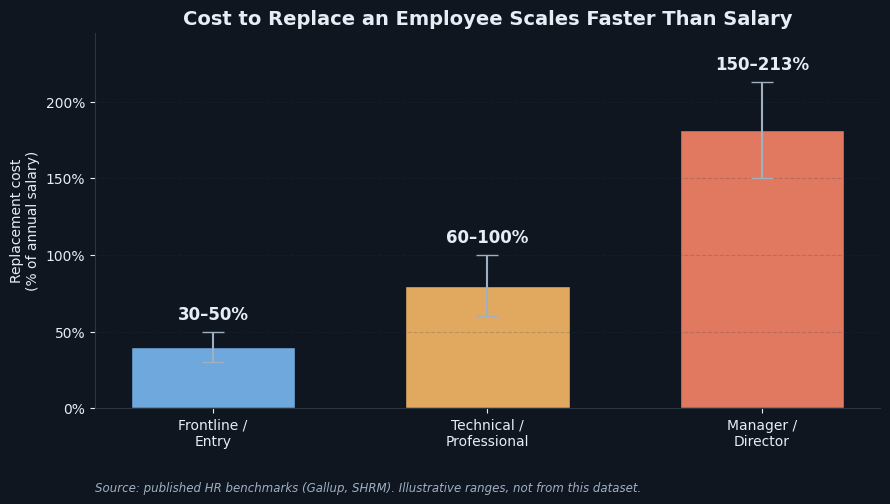

In [92]:
# Illustrative replacement-cost benchmark (EXTERNAL data — not from this dataset)
tiers = ['Frontline /\nEntry', 'Technical /\nProfessional', 'Manager /\nDirector']
low = [30, 60, 150]; high = [50, 100, 213]; mid = [(l+h)/2 for l,h in zip(low,high)]
elo = [m-l for m,l in zip(mid,low)]; ehi = [h-m for h,m in zip(high,mid)]
cols = ['#6FA8DC', '#E0A95F', '#E0795F']

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(tiers, mid, yerr=[elo,ehi], capsize=8, color=cols, edgecolor=BG, width=0.6,
              error_kw=dict(ecolor=MUTED, lw=1.5))
for b,l,h in zip(bars,low,high):
    ax.text(b.get_x()+b.get_width()/2, h+8, f'{l}–{h}%', ha='center', fontsize=12, fontweight='bold', color=FG)
ax.set_ylabel('Replacement cost\n(% of annual salary)')
ax.set_title('Cost to Replace an Employee Scales Faster Than Salary', fontsize=14, fontweight='bold')
ax.set_ylim(0, 245); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.2, linestyle='--')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.text(0.0, -0.22, 'Source: published HR benchmarks (Gallup, SHRM). Illustrative ranges, not from this dataset.',
        transform=ax.transAxes, fontsize=8.5, color=MUTED, style='italic')
plt.tight_layout(); plt.savefig('replacement_cost.png', dpi=150, bbox_inches='tight'); plt.show()

---
### Log-Transform Comparison


In [93]:
# Train a second model on log(MonthlyIncome), then exponentiate predictions
# back to dollar space for an apples-to-apples MAE/RMSE comparison.
model_log = LinearRegression().fit(X_train, np.log(y_train))
y_pred_log_dollars = np.exp(model_log.predict(X_test))

mae_log  = mean_absolute_error(y_test, y_pred_log_dollars)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_dollars))

print('=== Log-Transform Model vs Original ===')
print(f'                       Original    Log-target')
print(f'  MAE  ($)             {mae:>9,.0f}    {mae_log:>9,.0f}')
print(f'  RMSE ($)             {rmse:>9,.0f}    {rmse_log:>9,.0f}')
print(f'  RMSE − MAE gap       {rmse-mae:>9,.0f}    {rmse_log-mae_log:>9,.0f}')
print()
print('Interpretation:')
print('  A smaller RMSE-MAE gap indicates fewer extreme outliers.')
print('  This is preliminary; a full evaluation would also re-check residual')
print('  patterns and per-segment errors on the log model.')


=== Log-Transform Model vs Original ===
                       Original    Log-target
  MAE  ($)                   852        1,051
  RMSE ($)                 1,136        1,408
  RMSE − MAE gap             284          357

Interpretation:
  A smaller RMSE-MAE gap indicates fewer extreme outliers.
  This is preliminary; a full evaluation would also re-check residual
  patterns and per-segment errors on the log model.


---
## Should HR Deploy This Model? **Not yet.**

**Wrong systematically, not randomly.**

- ✕ **Not reliable** for setting or benchmarking individual salaries — errors are too large and too structured (the JobLevel-bucket effect).
- ✓ **Valuable as a diagnostic** — residuals flag where pay diverges from job-level structure, which is useful HR signal in itself.

**From the rubric — what comes next**

| Rubric question | Answer |
|---|---|
| *What features are missing?* | Within-level signals — performance, bonus history, time-in-role — plus an **attrition flag** to link pay gaps to who actually leaves. |
| *Which additional data would improve performance?* | Comparable-company / market salary data — for **calibration and benchmarking**, not blind training. |
| *What would you improve?* | Start with a proper **train / validation / test split** — this model was *fit*, not *selected*. |

We also tested the obvious fix — log-transforming the target — and it **made errors worse** (see appendix), so it is not recommended. Critically, only error analysis surfaced any of this: plain analysis of the raw salaries would never have told us *where* the model can't be trusted.

---
### References (replacement-cost benchmarks)
- "The Cost of Replacing an Employee and the Role of Financial Wellness" — Enrich
- "The Cost of Losing Employees" — Payscale
- "The True Cost of Employee Turnover: Hidden Expenses That Hurt Your Business" — ClearlyRated
- Gallup, "This Fixable Problem Costs U.S. Businesses $1 Trillion"; SHRM, replacement ≈ 6–9 months of salary